# IMPORTS

In [68]:
import glob
import pandas as pd
import os
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import numpy as np
from sklearn import tree
from scipy.ndimage import gaussian_filter1d
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.tree import DecisionTreeClassifier,export_graphviz
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
import neurokit2 as nk

# FILTERS

In [69]:
def butter_lowpass_filter(data, cutoff, fs, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    y = filtfilt(b, a, data)
    return y

def butter_highpass_filter(data, cutoff, fs, order=2):
    nyquist = 0.5 * fs
    normal_cutoff = cutoff / nyquist
    b, a = butter(order, normal_cutoff, btype='highpass', analog=False)
    y = filtfilt(b, a, data)
    return y

def bandpass_filter(data, lowcut, highcut, fs, order=2):
    nyq = 0.5 * fs
    b, a = butter(order, [lowcut / nyq, highcut / nyq], btype='band')
    return filtfilt(b, a, data)

# Feature Extraction

In [70]:
def feature_extraction(data, state):
    df = data['filtered_EA'].dropna().values    
    return {
        'mean': [np.mean(df)],
        'std': [np.std(df)],
        'max': [np.max(df)],
        'min': [np.min(df)],
        'median': [np.median(df)],
        'label': state
    }

# EA Detection

In [71]:
def ea_detection(csv_file_path):
    # Load data
    df = pd.read_csv(csv_file_path)
    df['time[s]'] = (df['LocalTimestamp'] - df['LocalTimestamp'].iloc[0])

    df = df.loc[(df['time[s]'] > 120) & (df['time[s]']  < (df['time[s]'].iloc[-1])-120)]

   
    ea_raw = df['EA'].astype(float)
  

    time = df['time[s]']
    sampling_rate = 15          
    
    ea_filtered = bandpass_filter(ea_raw, 0.1, 5, sampling_rate)

    df['filtered_EA'] = ea_filtered

    #gaussian not necessary for ea
    # first cut first and last set of seconds
    #emotibit, collecting data on forehead

    # plt.figure(figsize=(14, 5))
    # plt.plot(time, ea_raw, color = 'red')
    # plt.title("Raw EA")
    # plt.xlabel("Time (s)")
    # plt.ylabel("EA")
    # #plt.xlim(120, (df['time[s]'].iloc[-1])-120)
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # plt.show()

    # plt.figure(figsize=(14, 5))
    # plt.plot(time, smoothed, color = 'red')
    # plt.title("Filtered EA")
    # plt.xlabel("Time (s)")
    # plt.ylabel("EA")
    # #plt.xlim(120, (df['time[s]'].iloc[-1])-120)
    # plt.legend()
    # plt.grid(True, alpha=0.3)
    # plt.tight_layout()
    # plt.show()

    signals, info = nk.eda_process(ea_filtered, sampling_rate=15, method='neurokit', report=None)

    nk.eda_plot(signals, info)

    return signals[['SCR_Onsets', 'SCR_Peaks',  'SCR_Height' , 'SCR_Amplitude', 'SCR_RiseTime', 'SCR_Recovery', 'SCR_RecoveryTime']]


# ML Model

In [72]:
def pred_tree(frames):
    X = frames.drop('label', axis=1) #drops 'label' column
    y = frames['label']

    #splits into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

    dt_model = DecisionTreeClassifier(criterion='entropy', max_depth=3)

    #trains model?
    dt_model.fit(X_train, y_train)

    #predicts 'y' values with test 'x' values
    y_pred = dt_model.predict(X_test)

    #checks accuracy of predicted 'y' against true 'y'
    acc = accuracy_score(y_test, y_pred)

    # confusion matrix
    dt_cm = confusion_matrix(y_test, y_pred, labels=dt_model.classes_)

    # precision, recall, f1 score
    print(classification_report(y_test, y_pred))

    print("Accuracy on set:", acc)

    print("--------------------------------------------")

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
    rf_model.fit(X_train, y_train)
    rf_pred = rf_model.predict(X_test)

    print(classification_report(y_test, rf_pred))
    print("Random Forest Accuracy:", rf_model.score(X_test, y_test))


engaged\2025-07-08_16-29-06-899344_EA-checkpoint.csv:
engaged\2025-07-10_15-09-52-005859_EA.csv:
engaged\2025-07-15_18-53-07-705441_EA.csv:
engaged\2025-07-15_19-32-05-631421_EA.csv:
engaged\2025-07-16_18-00-15-608675_EA.csv:
engaged\2025-07-17_15-27-24-195986_EA.csv:
engaged\2025-07-17_17-29-34-069561_EA.csv:
engaged\2025-07-17_19-16-34-115458_EA.csv:
              precision    recall  f1-score   support

     engaged       0.51      0.99      0.68     18305
     relaxed       0.83      0.04      0.07     17877

    accuracy                           0.52     36182
   macro avg       0.67      0.51      0.37     36182
weighted avg       0.67      0.52      0.38     36182

Accuracy on set: 0.5201205019070256
--------------------------------------------
              precision    recall  f1-score   support

     engaged       0.51      0.99      0.68     18305
     relaxed       0.79      0.04      0.08     17877

    accuracy                           0.52     36182
   macro avg       

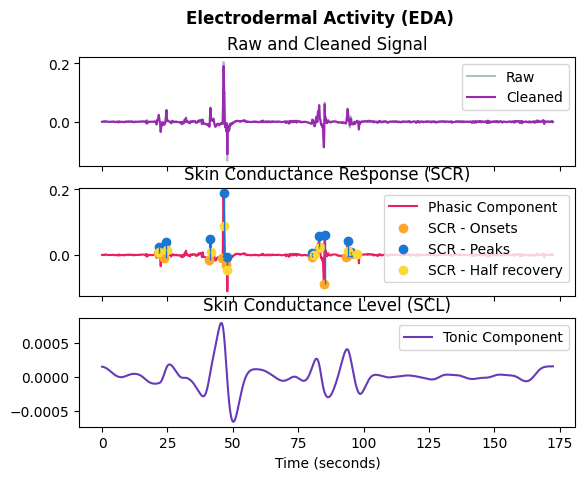

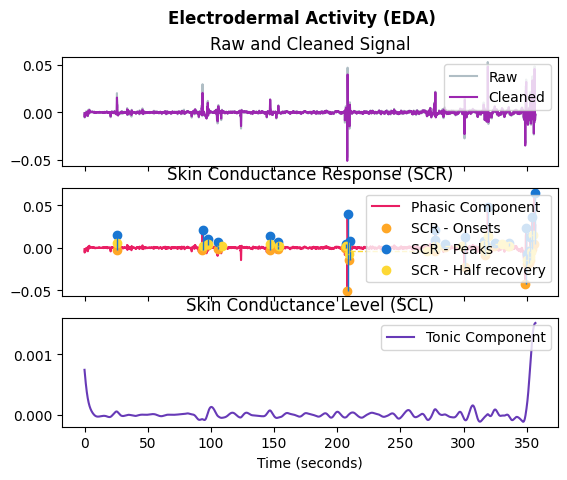

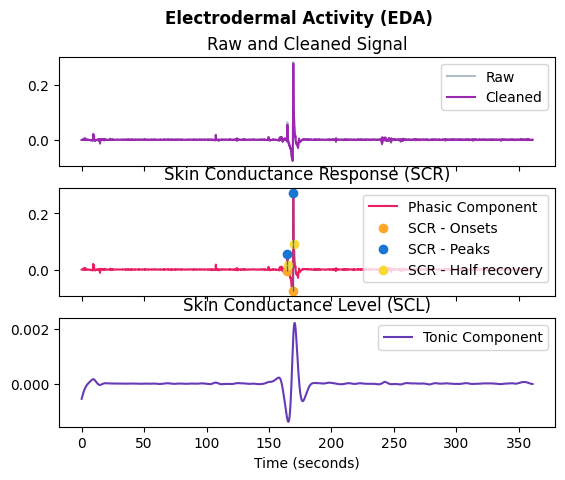

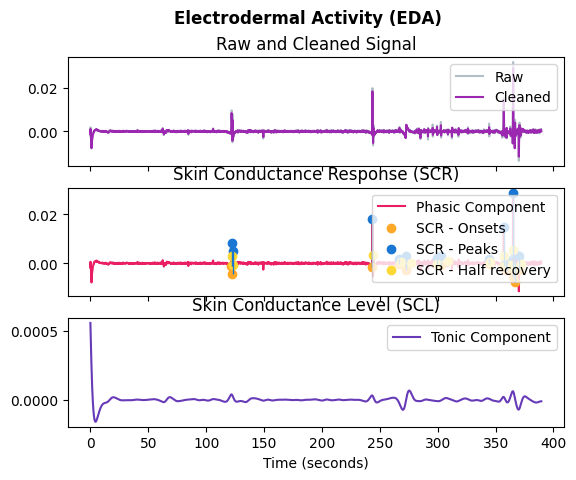

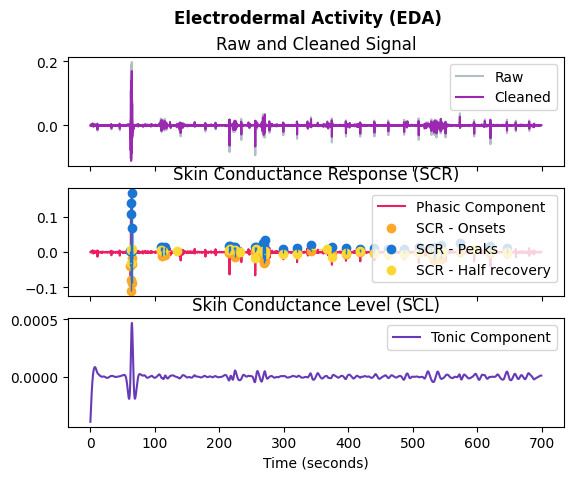

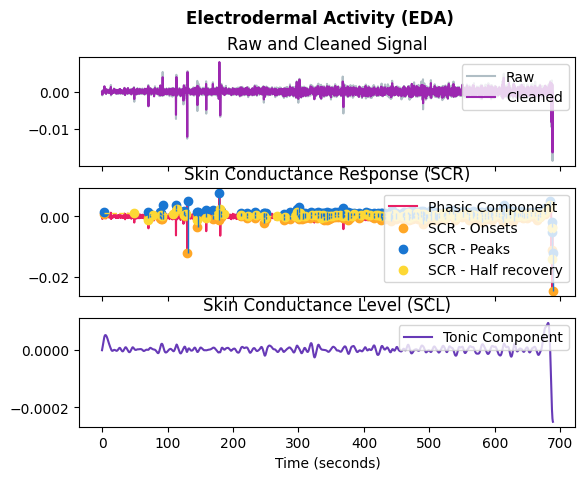

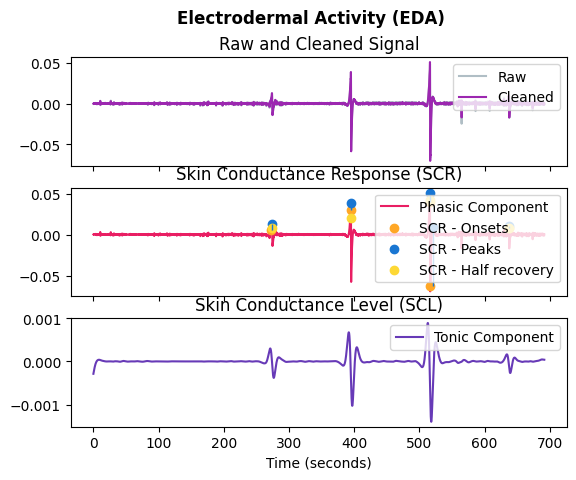

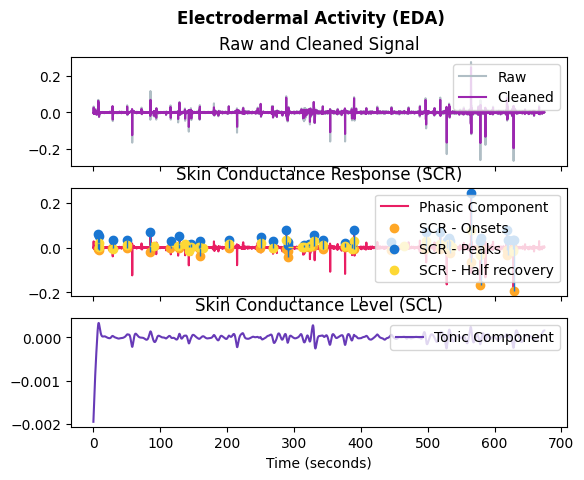

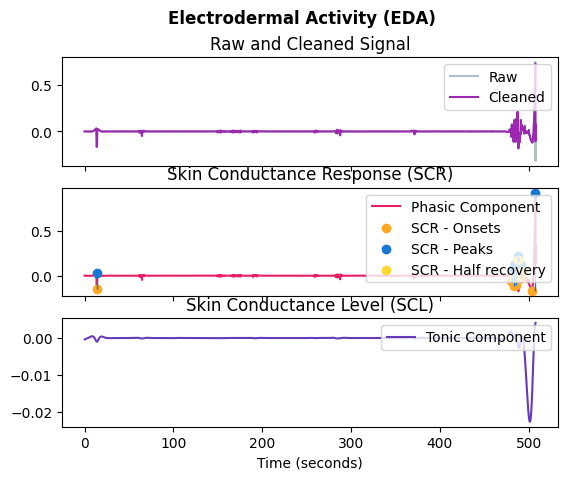

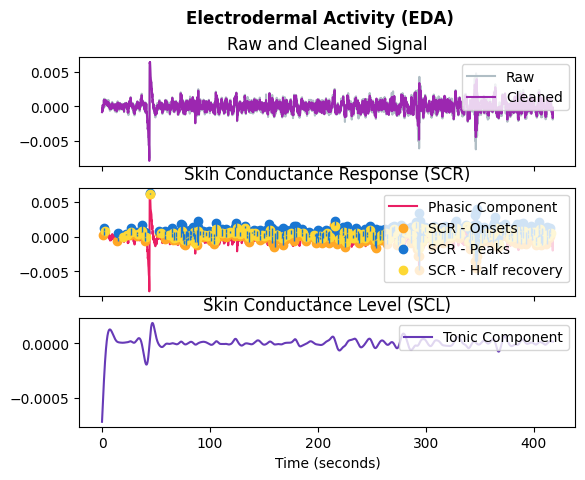

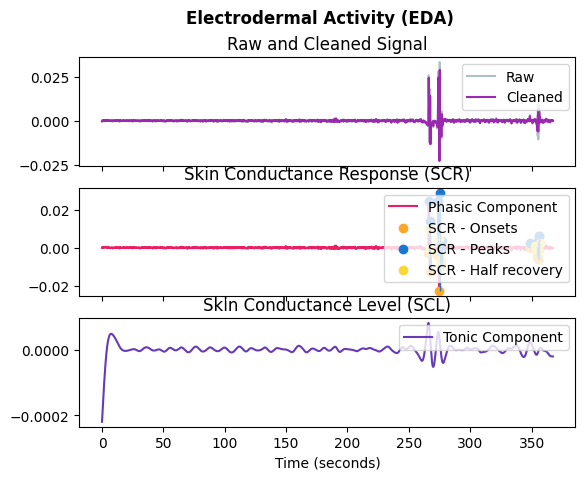

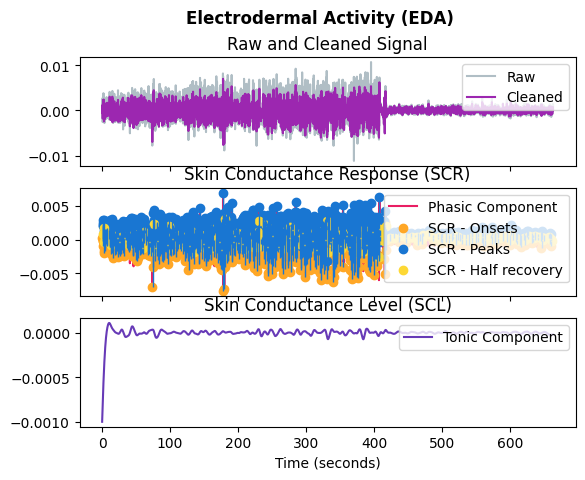

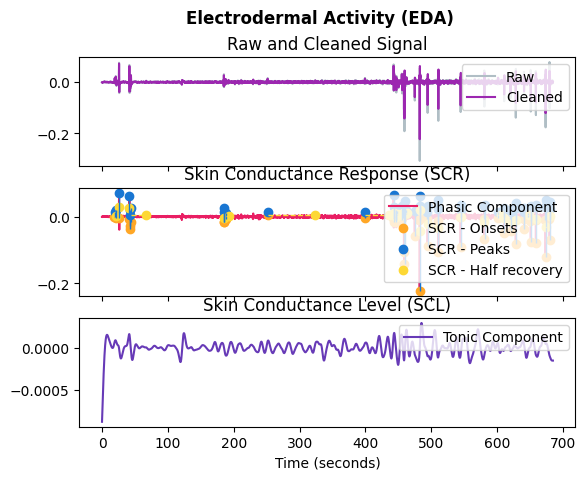

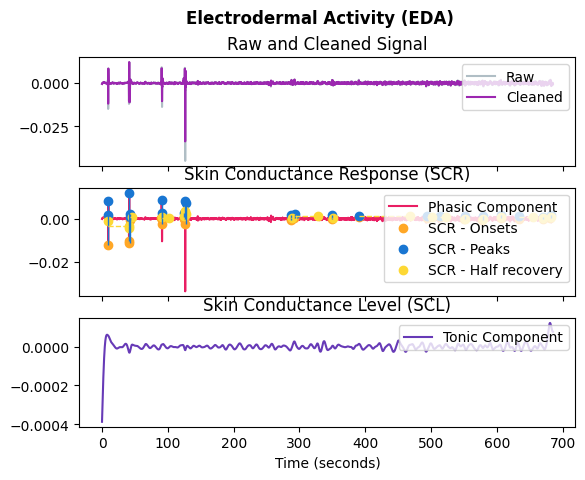

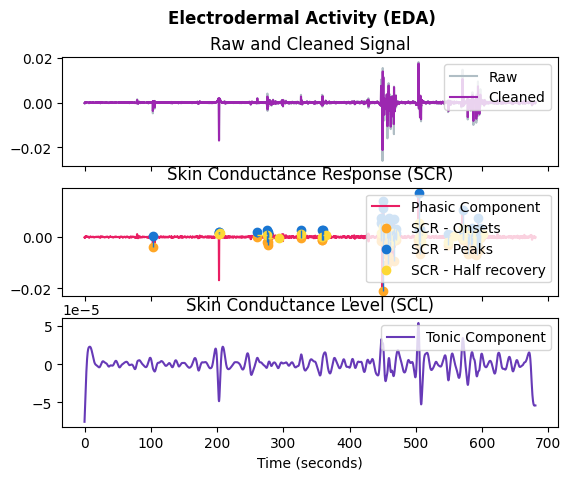

In [73]:
# Run detection

engaged_filenames = glob.glob("engaged/*.csv")

data = pd.DataFrame()

for file in engaged_filenames:
    df = ea_detection(file)
    df['label'] =  'engaged'
    data = pd.concat([data, pd.DataFrame(df)], ignore_index = True)

relaxed_filenames = glob.glob("relaxed/*.csv")

for file in relaxed_filenames:
    df = ea_detection(file)
    df['label'] = 'relaxed'
    data = pd.concat([data, pd.DataFrame(df)], ignore_index = True)

pred_tree(data)